# Proyecto final EA2: De los datos al conocimiento

## Predicción de estrategia de parada en pits en Fórmula 1

Este notebook desarrolla un flujo completo de ciencia de datos usando el dataset `f1_strategy_dataset_v4.csv`.

## 1. Objetivo del proyecto

Predecir si un piloto realizará una parada en pits en la siguiente vuelta (`PitNextLap`) y complementar el análisis con segmentación no supervisada de vueltas de carrera.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

RANDOM_STATE = 42

# Rutas robustas para ejecutar desde VS Code, Jupyter o terminal.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == 'notebook':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_IN = PROJECT_ROOT / 'Dataset' / 'Antes' / 'f1_strategy_dataset_v4_ENTRADA.csv'
DATA_OUT = PROJECT_ROOT / 'Dataset' / 'Despues' / 'f1_strategy_dataset_v4_SALIDA.csv'
PLOTS_DIR = PROJECT_ROOT / 'Visualizaciones' / 'Graficos'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_OUT.parent.mkdir(parents=True, exist_ok=True)

print('Raíz del proyecto:', PROJECT_ROOT)
print('Dataset de entrada:', DATA_IN)


Raíz del proyecto: /Users/alumno25/Downloads/Proyecto_Final_EA2_F1_Strategy_Entrega
Dataset de entrada: /Users/alumno25/Downloads/Proyecto_Final_EA2_F1_Strategy_Entrega/Dataset/Antes/f1_strategy_dataset_v4_ENTRADA.csv


In [15]:
df = pd.read_csv(DATA_IN)
df.head()


,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


In [16]:
print('Dimensiones:', df.shape)
display(df.info())
display(df.describe(include='all'))

Dimensiones: (101371, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  object 
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  object 
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  object 
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101371 non-null  int64  
 13  RaceProgress            101371 non-null  float64

None

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
count,101371,101371.000000,101305,101371.000000,101371.000000,101371.000000,101371.000000,101371,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000
unique,31,NaN,5,NaN,NaN,NaN,NaN,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NOR,NaN,HARD,NaN,NaN,NaN,NaN,Dutch Grand Prix,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,5436,NaN,44967,NaN,NaN,NaN,NaN,5486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,30.444841,NaN,2.046394,14.549339,9.759132,92.587188,NaN,2023.589685,-0.203891,-29.550051,0.251581,0.254797,0.432618,0.386521,-0.004636
std,NaN,18.146942,NaN,0.948797,10.313385,5.406456,33.231414,NaN,1.098518,45.344910,70.235759,0.433924,0.435749,0.258129,0.259906,3.912725
min,NaN,1.000000,NaN,1.000000,1.000000,1.000000,67.012000,NaN,2022.000000,-2403.895000,-274.564000,0.000000,0.000000,0.012821,0.012821,-18.000000
25%,NaN,15.000000,NaN,1.000000,7.000000,5.000000,82.021000,NaN,2023.000000,-7.253000,-51.054500,0.000000,0.000000,0.210526,0.172414,-2.000000
50%,NaN,30.000000,NaN,2.000000,13.000000,10.000000,91.167000,NaN,2024.000000,-0.027000,-21.678000,0.000000,0.000000,0.421053,0.333333,0.000000
75%,NaN,45.000000,NaN,3.000000,20.000000,14.000000,99.356000,NaN,2025.000000,5.705000,-3.725500,1.000000,1.000000,0.631579,0.562500,2.000000


## 2. Preparación y limpieza

Se revisan valores nulos, duplicados y tiempos extremos de vuelta. La variable `Compound` se imputa como `UNKNOWN` para conservar registros.

In [17]:
display(df.isna().sum())
print('Duplicados:', df.duplicated().sum())

df_clean = df.copy()
df_clean['Compound'] = df_clean['Compound'].fillna('UNKNOWN')

lo, hi = df_clean['LapTime (s)'].quantile([0.01, 0.99])
df_clean = df_clean[(df_clean['LapTime (s)'] >= lo) & (df_clean['LapTime (s)'] <= hi)].copy()

print('Rango aceptado LapTime:', round(lo, 3), 'a', round(hi, 3))
print('Dimensiones después de limpieza:', df_clean.shape)
# Guardar dataset procesado para la entrega final
df_clean.to_csv(DATA_OUT, index=False)
print('Dataset procesado guardado en:', DATA_OUT)


Driver                     0
LapNumber                  0
Compound                  66
Stint                      0
TyreLife                   0
Position                   0
LapTime (s)                0
Race                       0
Year                       0
LapTime_Delta              0
Cumulative_Degradation     0
PitStop                    0
PitNextLap                 0
RaceProgress               0
Normalized_TyreLife        0
Position_Change            0
dtype: int64

Duplicados: 0
Rango aceptado LapTime: 70.185 a 139.838
Dimensiones después de limpieza: (99343, 16)
Dataset procesado guardado en: /Users/alumno25/Downloads/Proyecto_Final_EA2_F1_Strategy_Entrega/Dataset/Despues/f1_strategy_dataset_v4_SALIDA.csv


## 3. Análisis exploratorio de datos

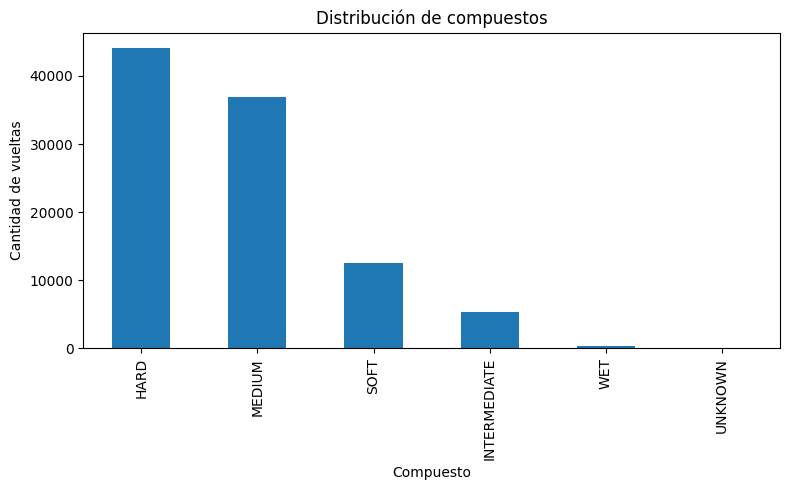

In [18]:
plt.figure(figsize=(8, 5))
df_clean['Compound'].value_counts().plot(kind='bar')
plt.title('Distribución de compuestos')
plt.xlabel('Compuesto')
plt.ylabel('Cantidad de vueltas')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '01_distribucion_compuestos.png', dpi=300, bbox_inches='tight')
plt.show()


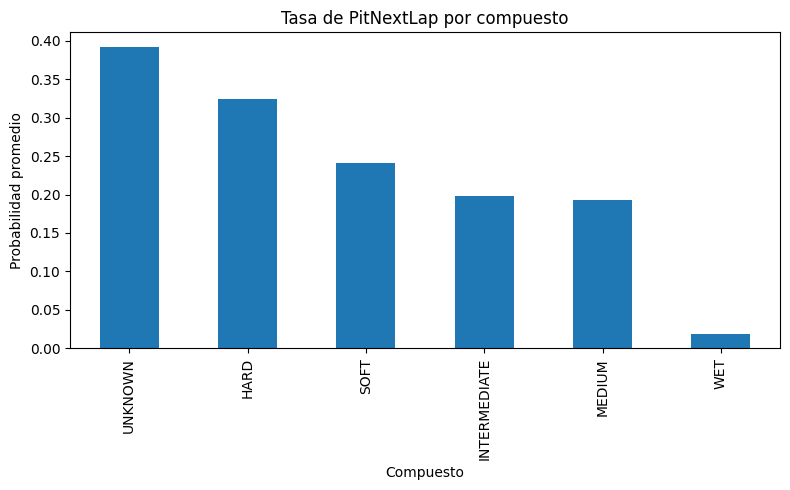

In [19]:
plt.figure(figsize=(8, 5))
df_clean.groupby('Compound')['PitNextLap'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Tasa de PitNextLap por compuesto')
plt.xlabel('Compuesto')
plt.ylabel('Probabilidad promedio')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '02_pitnext_por_compuesto.png', dpi=300, bbox_inches='tight')
plt.show()


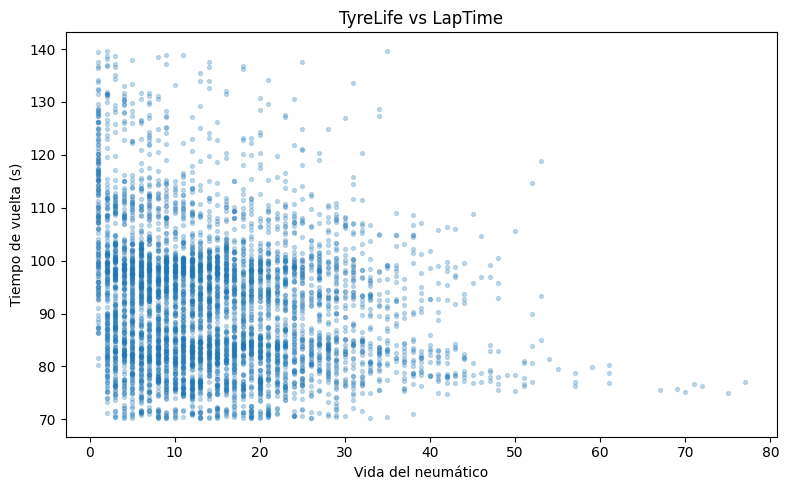

In [20]:
sample = df_clean.sample(min(5000, len(df_clean)), random_state=RANDOM_STATE)
plt.figure(figsize=(8, 5))
plt.scatter(sample['TyreLife'], sample['LapTime (s)'], alpha=0.25, s=8)
plt.title('TyreLife vs LapTime')
plt.xlabel('Vida del neumático')
plt.ylabel('Tiempo de vuelta (s)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '03_tyre_life_vs_laptime.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. Modelado supervisado

La variable objetivo es `PitNextLap`. Se comparan dos modelos base y luego se optimiza un árbol de decisión mediante `GridSearchCV`.

In [21]:
# Se usa una muestra para asegurar ejecución rápida en equipos académicos.
# Si el computador lo permite, se puede reemplazar model_df por df_clean.
model_df = df_clean.sample(n=min(8000, len(df_clean)), random_state=RANDOM_STATE)

features = ['Driver', 'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'Race', 'Year',
            'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Normalized_TyreLife',
            'Position_Change', 'LapNumber']

X = model_df[features]
y = model_df['PitNextLap']

categorical_features = ['Driver', 'Compound', 'Race']
numeric_features = [col for col in features if col not in categorical_features]

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

In [22]:
def evaluar_modelo(nombre, pipeline):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    return {
        'model': nombre,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_proba)
    }, y_pred

modelos = [
    ('Regresión Logística', Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=500, class_weight='balanced'))
    ])),
    ('Árbol Base', Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=RANDOM_STATE))
    ]))
]

resultados = []
for nombre, modelo in modelos:
    met, _ = evaluar_modelo(nombre, modelo)
    resultados.append(met)

metrics_df = pd.DataFrame(resultados)
display(metrics_df)

/Users/alumno25/Downloads/Proyecto_Final_EA2_F1_Strategy_Entrega/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/alumno25/Downloads/Proyecto_Final_EA2_F1_Strategy_Entrega/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/alumno25/Downloads/Proyecto_Final_EA2_F1_Strategy_Entrega/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/alumno25/Downloads/Proyecto_Final_EA2_F1_Strategy_Entrega/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/alumno25/Downloads/Proye

,model,accuracy,precision,recall,f1,auc
0,Regresión Logística,0.732500,0.493684,0.744444,0.593671,0.812469
1,Árbol Base,0.800417,0.580922,0.860317,0.693538,0.865240


## 5. Optimización de hiperparámetros

In [23]:
param_grid = {
    'model__max_depth': [4, 6, 8, 10],
    'model__min_samples_leaf': [20, 50]
}

pipeline_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE))
])

grid = GridSearchCV(pipeline_tree, param_grid, cv=3, scoring='f1')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

met_optimizado = {
    'model': 'Árbol Optimizado',
    'accuracy': accuracy_score(y_test, y_pred_best),
    'precision': precision_score(y_test, y_pred_best),
    'recall': recall_score(y_test, y_pred_best),
    'f1': f1_score(y_test, y_pred_best),
    'auc': roc_auc_score(y_test, y_proba_best)
}

metrics_df = pd.concat([metrics_df, pd.DataFrame([met_optimizado])], ignore_index=True)
print('Mejores hiperparámetros:', grid.best_params_)
display(metrics_df)

Mejores hiperparámetros: {'model__max_depth': 6, 'model__min_samples_leaf': 20}


,model,accuracy,precision,recall,f1,auc
0,Regresión Logística,0.732500,0.493684,0.744444,0.593671,0.812469
1,Árbol Base,0.800417,0.580922,0.860317,0.693538,0.865240
2,Árbol Optimizado,0.767500,0.535019,0.873016,0.663450,0.875627


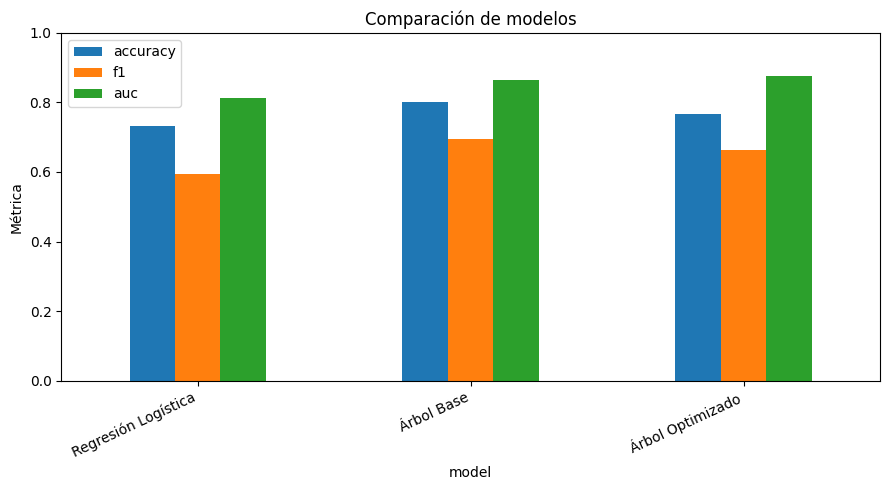

              precision    recall  f1-score   support

           0       0.94      0.73      0.82      1770
           1       0.54      0.87      0.66       630

    accuracy                           0.77      2400
   macro avg       0.74      0.80      0.74      2400
weighted avg       0.83      0.77      0.78      2400



,Pred 0,Pred 1
Real 0,1292,478
Real 1,80,550


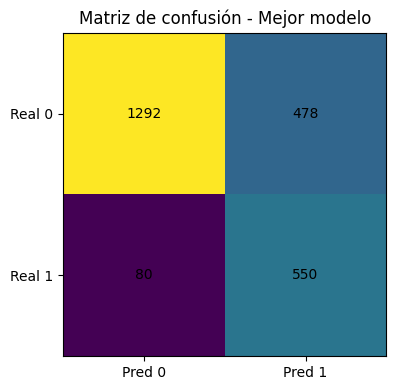

In [24]:
metrics_df.set_index('model')[['accuracy', 'f1', 'auc']].plot(kind='bar', figsize=(9, 5))
plt.title('Comparación de modelos')
plt.ylabel('Métrica')
plt.ylim(0, 1)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '04_metricas_modelos.png', dpi=300, bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred_best))
cm_df = pd.DataFrame(confusion_matrix(y_test, y_pred_best), index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1'])
display(cm_df)

plt.figure(figsize=(5, 4))
plt.imshow(cm_df, interpolation='nearest')
plt.title('Matriz de confusión - Mejor modelo')
plt.xticks([0, 1], ['Pred 0', 'Pred 1'])
plt.yticks([0, 1], ['Real 0', 'Real 1'])
for i in range(cm_df.shape[0]):
    for j in range(cm_df.shape[1]):
        plt.text(j, i, cm_df.iloc[i, j], ha='center', va='center')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '05_matriz_confusion.png', dpi=300, bbox_inches='tight')
plt.show()


## 6. Modelado no supervisado: K-Means + PCA

Se utiliza K-Means para segmentar vueltas de carrera y PCA para visualizar los clusters.

/Users/alumno25/Downloads/Proyecto_Final_EA2_F1_Strategy_Entrega/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/alumno25/Downloads/Proyecto_Final_EA2_F1_Strategy_Entrega/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/alumno25/Downloads/Proyecto_Final_EA2_F1_Strategy_Entrega/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/alumno25/Downloads/Proyecto_Final_EA2_F1_Strategy_Entrega/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/alumno25/Downloads/Proyecto_Final_EA2_F1_Strategy_Entrega/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current

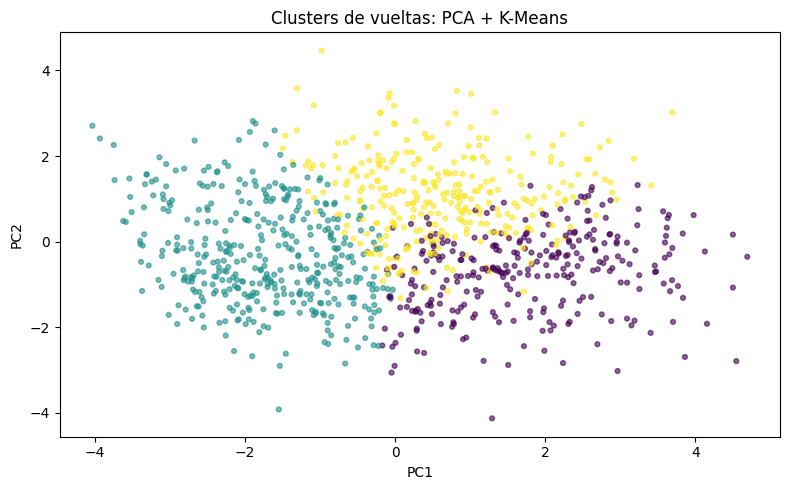

,LapNumber,TyreLife,Position,LapTime (s),RaceProgress,PitNextLap
Cluster,,,,,,
0,43.36,26.14,8.06,89.42,0.62,0.38
1,13.07,9.07,10.05,94.25,0.19,0.19
2,42.03,10.31,11.54,91.67,0.60,0.21


In [25]:
cluster_sample = model_df.sample(n=min(1000, len(model_df)), random_state=RANDOM_STATE)
Z = preprocessor.fit_transform(cluster_sample[features])

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
cluster_sample['Cluster'] = kmeans.fit_predict(Z)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(Z)

plt.figure(figsize=(8, 5))
plt.scatter(coords[:, 0], coords[:, 1], c=cluster_sample['Cluster'], alpha=0.6, s=12)
plt.title('Clusters de vueltas: PCA + K-Means')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '06_clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()

display(cluster_sample.groupby('Cluster')[['LapNumber','TyreLife','Position','LapTime (s)','RaceProgress','PitNextLap']].mean().round(2))


## 7. Conclusiones

- El problema se aborda como clasificación binaria para anticipar una parada en pits en la vuelta siguiente.
- El F1-score se usa como métrica principal porque interesa detectar correctamente la clase positiva, no solo acertar vueltas sin parada.
- Los clusters permiten entender perfiles de carrera: vueltas tempranas, vueltas avanzadas y estados intermedios de desgaste/rendimiento.
- Como mejora futura, se recomienda agregar clima, safety car, distancia con rivales, circuito y equipo para un modelo más realista.